Loaded eeg1.edf, sfreq=256.0 Hz, channels=21
Seizure interval: 0.40s - 0.47s (duration 0.07s)


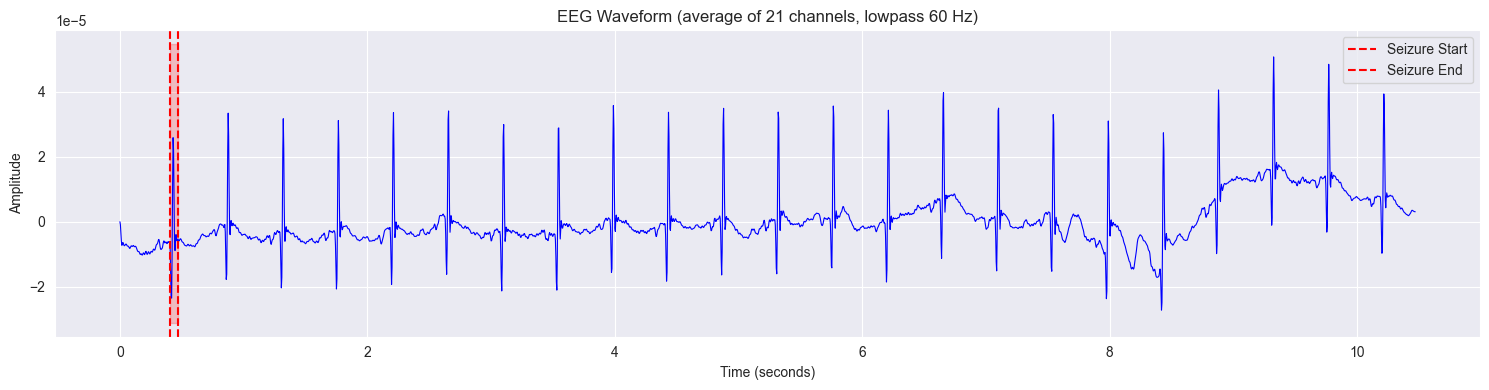

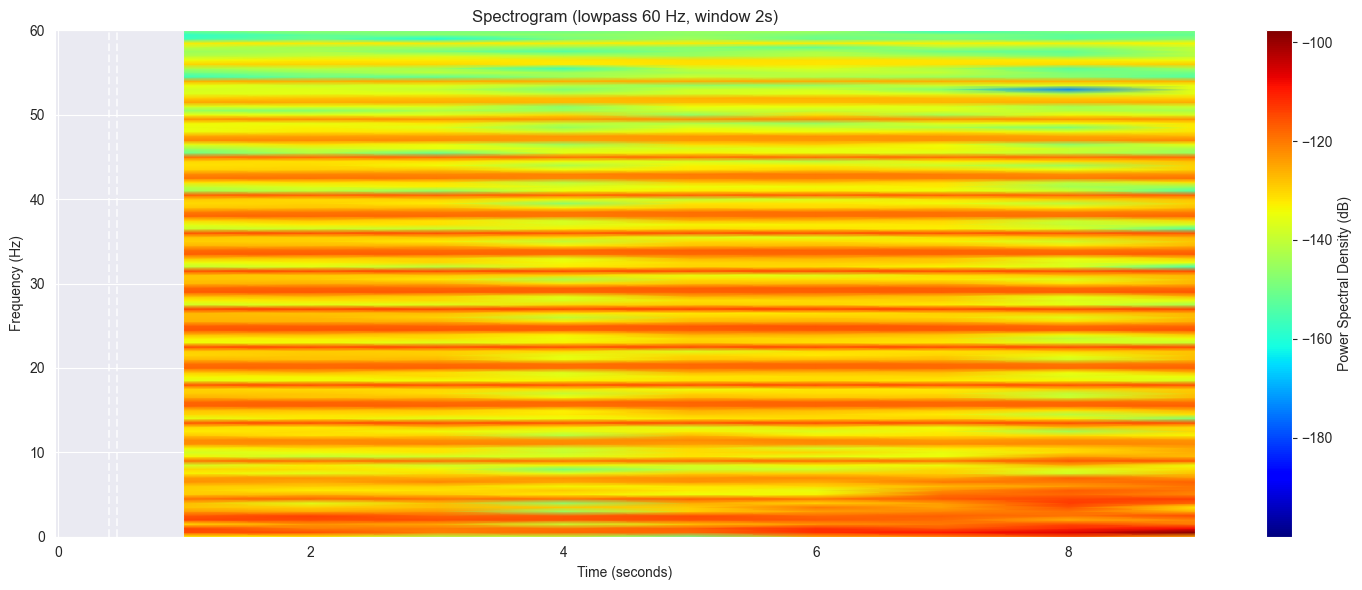

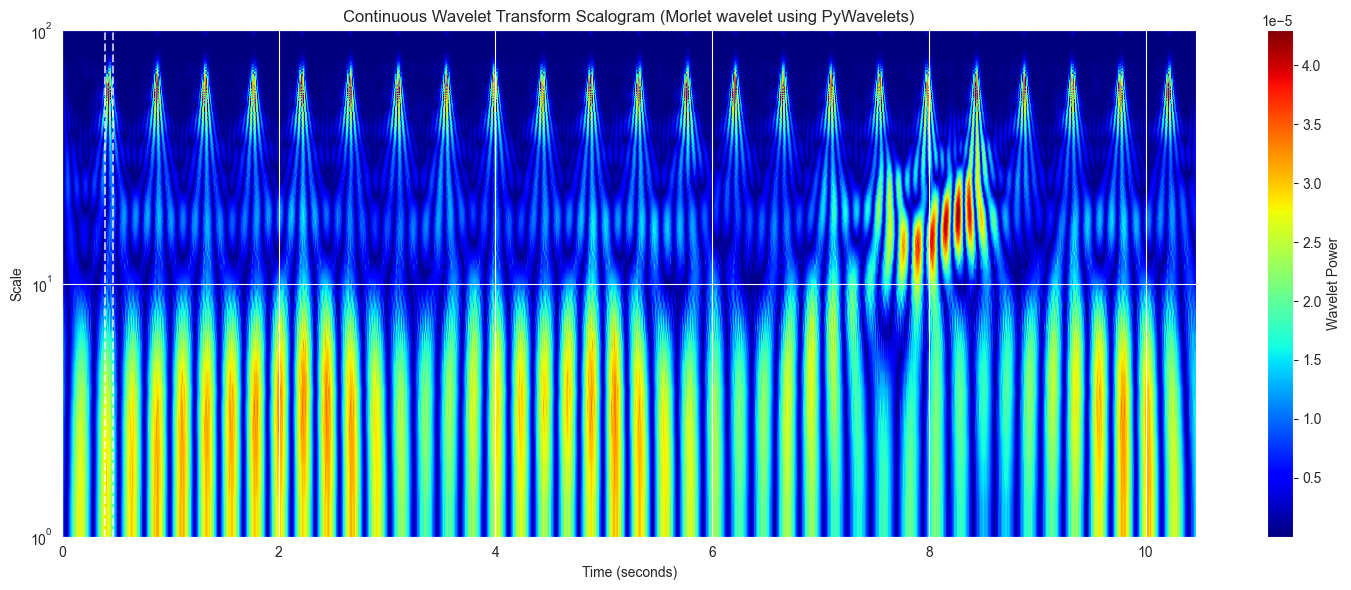

Analysis completed successfully.


In [10]:
import os
import urllib.request
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import loadmat
import pywt  # 新导入的库

# ========== Parameters ==========
EEG_FILE_NUM = 1
EXPERT = 'A'
BUFFER_TIME = 10.0
# ================================

# Download files if not present locally
edf_url = f"https://zenodo.org/record/2547147/files/eeg{EEG_FILE_NUM}.edf?download=1"
ann_url = "https://zenodo.org/record/2547147/files/annotations_2017.mat?download=1"
edf_file = f"eeg{EEG_FILE_NUM}.edf"
ann_file = "annotations_2017.mat"

if not os.path.exists(edf_file):
    print(f"Downloading {edf_file} ...")
    urllib.request.urlretrieve(edf_url, edf_file)
if not os.path.exists(ann_file):
    print("Downloading annotations_2017.mat ...")
    urllib.request.urlretrieve(ann_url, ann_file)

# Load EEG
raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
sfreq = raw.info['sfreq']
n_channels = len(raw.ch_names)
print(f"Loaded {edf_file}, sfreq={sfreq} Hz, channels={n_channels}")

# Load annotations
mat = loadmat(ann_file)
all_annotations = mat['annotat_new'].squeeze()   # shape (3, n_samples)
expert_idx = ord(EXPERT) - ord('A')
seizure_vec = all_annotations[expert_idx].astype(int).flatten()

# Find first seizure block using transitions
padded = np.concatenate(([0], seizure_vec, [0]))
diff_padded = np.diff(padded)
block_starts = np.where(diff_padded == 1)[0]
block_ends = np.where(diff_padded == -1)[0] - 1

if len(block_starts) == 0:
    raise RuntimeError("No seizure annotated for this expert.")

start_idx = block_starts[0]
end_idx = block_ends[0]
start_time = start_idx / sfreq
end_time = end_idx / sfreq
print(f"Seizure interval: {start_time:.2f}s - {end_time:.2f}s (duration {end_time-start_time:.2f}s)")

# Crop with buffer
crop_start = max(0, start_time - BUFFER_TIME)
crop_end = min(raw.times[-1], end_time + BUFFER_TIME)
raw_crop = raw.copy().crop(tmin=crop_start, tmax=crop_end)
data, times = raw_crop[:, :]
avg_signal = np.mean(data, axis=0)

# Lowpass filter at 60 Hz
nyquist = sfreq / 2
b, a = signal.butter(4, 60/nyquist, btype='low')
filtered = signal.filtfilt(b, a, avg_signal)

# Figure 1: Waveform
plt.figure(figsize=(15, 4))
plt.plot(times, filtered, 'b-', linewidth=0.8)
plt.axvline(start_time, color='r', linestyle='--', label='Seizure Start')
plt.axvline(end_time, color='r', linestyle='--', label='Seizure End')
plt.fill_betweenx(plt.ylim(), start_time, end_time, alpha=0.2, color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'EEG Waveform (average of {n_channels} channels, lowpass 60 Hz)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Figure 2: Spectrogram
nperseg = int(2 * sfreq)
nfft = nperseg
f_stft, t_stft, Zxx = signal.spectrogram(filtered, fs=sfreq,
                                          nperseg=nperseg,
                                          noverlap=nperseg//2,
                                          nfft=nfft)
plt.figure(figsize=(15, 6))
plt.pcolormesh(t_stft, f_stft, 10*np.log10(Zxx + 1e-20), shading='gouraud', cmap='jet')
plt.ylim(0, 60)
plt.colorbar(label='Power Spectral Density (dB)')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (seconds)')
plt.title('Spectrogram (lowpass 60 Hz, window 2s)')
plt.axvline(start_time, color='w', linestyle='--', alpha=0.7)
plt.axvline(end_time, color='w', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ------------------ Figure 3: Wavelet Scalogram (using pywt.cwt) ------------------
freqs = np.geomspace(1, 60, 200)
wavelet_name = 'morl'  # 使用 Morlet 小波

# 选择尺度（scale），这里我们根据需要的频率范围来选择合适的尺度
scales = np.geomspace(1, 100, 200)  # 尺度范围，与频率成反比
coefficients, _ = pywt.cwt(filtered, scales, wavelet_name, 1/sfreq)

plt.figure(figsize=(15, 6))
plt.imshow(np.abs(coefficients), aspect='auto', origin='lower',
           extent=[times[0], times[-1], scales[-1], scales[0]], cmap='jet')
plt.yscale('log')
plt.ylim(1, max(scales))
plt.xlabel('Time (seconds)')
plt.ylabel('Scale')
plt.colorbar(label='Wavelet Power')
plt.title('Continuous Wavelet Transform Scalogram (Morlet wavelet using PyWavelets)')
plt.axvline(start_time, color='w', linestyle='--', alpha=0.7)
plt.axvline(end_time, color='w', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Analysis completed successfully.")